## Q1.Supervised Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('q1_heart_disease.csv')


In [2]:
df

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0
...,...,...,...,...,...,...,...,...,...,...,...,...
795,60,0,asymptomatic,147.0,197.0,0,left_ventricular_hypertrophy,152,0,3.1,flat,1
796,40,1,asymptomatic,125.0,257.0,0,normal,151,0,0.7,down,0
797,45,1,asymptomatic,120.0,192.0,0,st_t_wave_abnormality,128,0,2.7,up,1
798,37,0,non_anginal,112.0,303.0,0,left_ventricular_hypertrophy,145,0,0.9,flat,0


In [3]:
# Load Dataset

df = pd.read_csv('q1_heart_disease.csv')

# Clean column names
df.columns = df.columns.str.strip()

print("Columns:", df.columns)
print(df.head())

target_col = df.columns[-1]

X = df.drop(target_col, axis=1)
y = df[target_col]


# Column Types

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())


Columns: Index(['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol',
       'fasting_bs', 'resting_ecg', 'max_hr', 'exercise_angina', 'oldpeak',
       'st_slope', 'heart_disease'],
      dtype='object')
   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0           0   
3   72    1     asymptomatic       114.0        177.0           0   
4   37    1      non_anginal       149.0        271.0           0   

                    resting_ecg  max_hr  exercise_angina  oldpeak st_slope  \
0  left_ventricular_hypertrophy     169                0      0.4       up   
1         st_t_wave_abnormality     121                1      1.1       up   
2                        normal     183                1      0.2       up   
3         st_t_wave_abnormality     150                0    

## EDA 

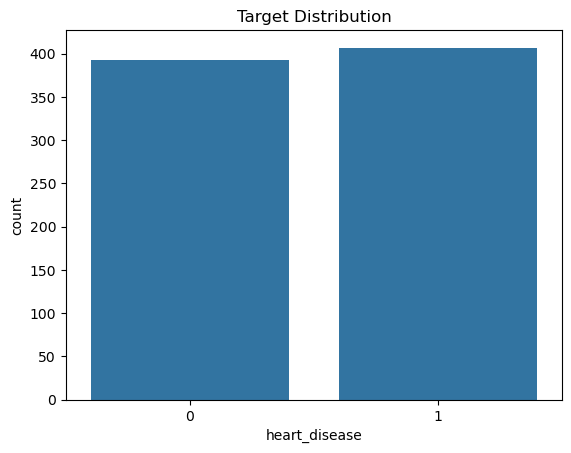

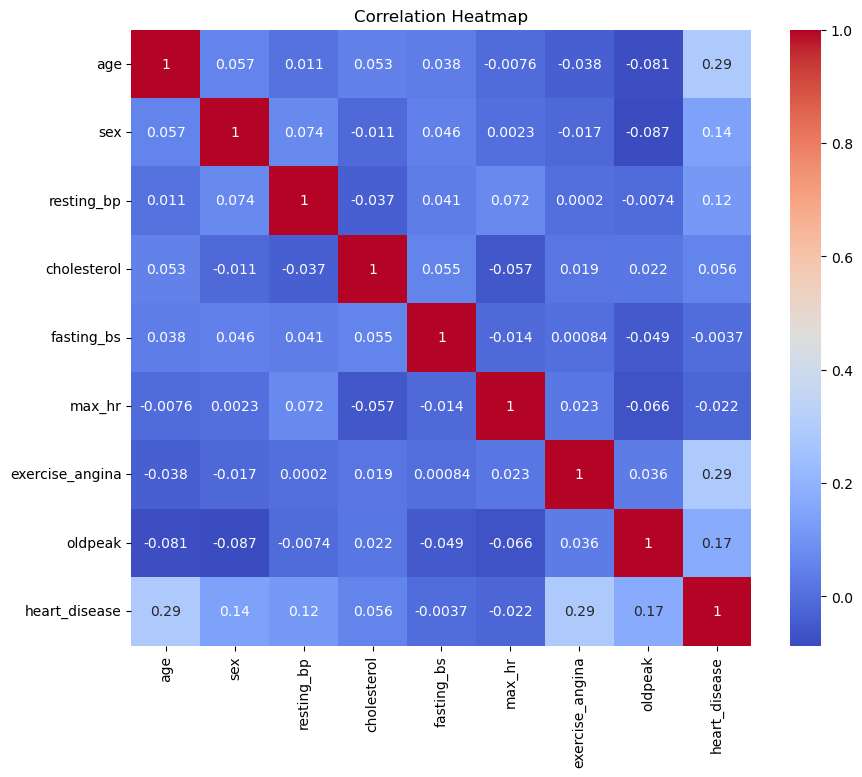

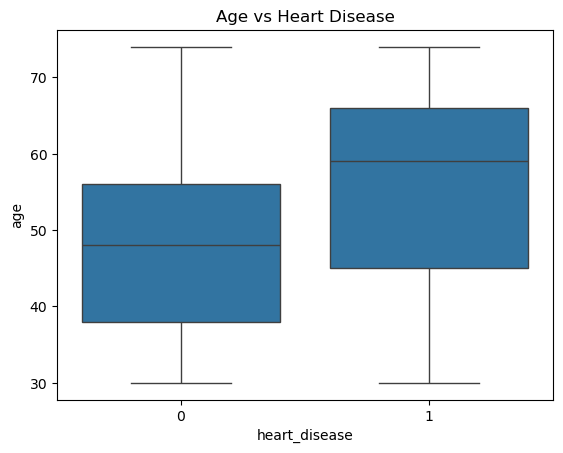

In [4]:
# EDA

sns.countplot(x=target_col, data=df)
plt.title("Target Distribution")
plt.show()


# Features & Target

X = df.drop(target_col, axis=1)
y = df[target_col]


# Column Types

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()


# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Age vs Heart Disease
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

## Preprocessing

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

 # Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessing Pipeline

# Preprocessing

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])


In [6]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## Models

 Logistic Regression 
Accuracy: 0.8125
              precision    recall  f1-score   support

           0       0.83      0.78      0.81        79
           1       0.80      0.84      0.82        81

    accuracy                           0.81       160
   macro avg       0.81      0.81      0.81       160
weighted avg       0.81      0.81      0.81       160



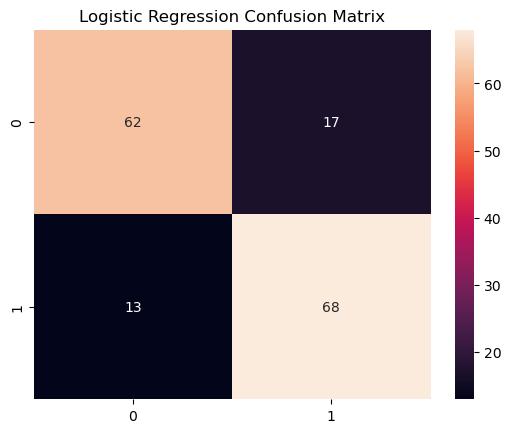


Interpretation:
Logistic Regression provides a baseline model with a linear boundary.

 Random Forest 
Accuracy: 0.7875
              precision    recall  f1-score   support

           0       0.80      0.76      0.78        79
           1       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



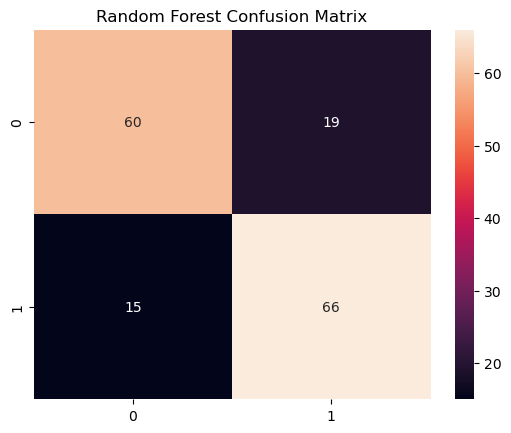


Interpretation:
Random Forest captures non-linear patterns and performs better.


In [7]:
# Logistic Regression

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print(" Logistic Regression ")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

print("\nInterpretation:")
print("Logistic Regression provides a baseline model with a linear boundary.")


# Random Forest

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("\n Random Forest ")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

print("\nInterpretation:")
print("Random Forest captures non-linear patterns and performs better.")


## Hyperparameter Tuning


Best Parameters: {'model__max_depth': 5, 'model__n_estimators': 50}

 Tuned Random Forest 
Accuracy: 0.79375
              precision    recall  f1-score   support

           0       0.83      0.73      0.78        79
           1       0.77      0.85      0.81        81

    accuracy                           0.79       160
   macro avg       0.80      0.79      0.79       160
weighted avg       0.80      0.79      0.79       160



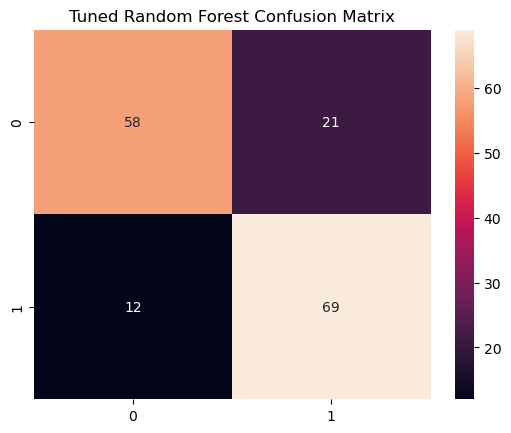

In [8]:
# Hyperparameter Tuning

param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [None, 5, 10]
}

grid = GridSearchCV(rf_pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("\n Tuned Random Forest ")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d')
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()


In [9]:
# Final Comparison

print("\n Model Comparison ")
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("Tuned RF:", accuracy_score(y_test, y_pred_best))


# Final Conclusion

print("\nFinal Conclusion:")
print("Missing values were handled using imputation.")
print("Random Forest outperforms Logistic Regression, indicating non-linear patterns.")
print("Hyperparameter tuning further improves performance.")



 Model Comparison 
Logistic Regression: 0.8125
Random Forest: 0.7875
Tuned RF: 0.79375

Final Conclusion:
Missing values were handled using imputation.
Random Forest outperforms Logistic Regression, indicating non-linear patterns.
Hyperparameter tuning further improves performance.
